In [1]:
import os

# This lets you see exactly where your unzipped files landed
for root, dirs, files in os.walk('/kaggle/input'):
    print(f"Folder: {root}")
    # Print the first 5 files just to check
    for name in files[:5]:
        print(f"  File: {name}")

Folder: /kaggle/input
Folder: /kaggle/input/datasets
Folder: /kaggle/input/datasets/pratikkarki106
Folder: /kaggle/input/datasets/pratikkarki106/fruits-classification
Folder: /kaggle/input/datasets/pratikkarki106/fruits-classification/fruits-360
  File: LICENSE
  File: README.md
Folder: /kaggle/input/datasets/pratikkarki106/fruits-classification/fruits-360/Training
Folder: /kaggle/input/datasets/pratikkarki106/fruits-classification/fruits-360/Training/Dates 1
  File: r_305_100.jpg
  File: r_239_100.jpg
  File: 185_100.jpg
  File: r_199_100.jpg
  File: r_287_100.jpg
Folder: /kaggle/input/datasets/pratikkarki106/fruits-classification/fruits-360/Training/Guava 1
  File: r_305_100.jpg
  File: 139_100.jpg
  File: 128_100.jpg
  File: r_239_100.jpg
  File: 185_100.jpg
Folder: /kaggle/input/datasets/pratikkarki106/fruits-classification/fruits-360/Training/Rambutan 1
  File: r_305_100.jpg
  File: r_287_100.jpg
  File: 73_100.jpg
  File: r_306_100.jpg
  File: 112_100.jpg
Folder: /kaggle/input/da

In [26]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#Defininig path to training data
train_dir = '/kaggle/input/datasets/pratikkarki106/fruits-classification/fruits-360/Training'

#Get the list of class directories or number of classification need to be done
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
classes.sort()
print(f"Detected classes: {classes}")

Detected classes: ['Apple 8', 'Banana Lady Finger 1', 'Blueberry 1', 'Carambola 1', 'Dates 1', 'Fig 1', 'Guava 1', 'Kiwi 1', 'Mango 1', 'Orange 1', 'Pepper 2', 'Pineapple 1', 'Rambutan 1', 'Strawberry 1', 'Watermelon 1']


Visualization setup on 2 rows

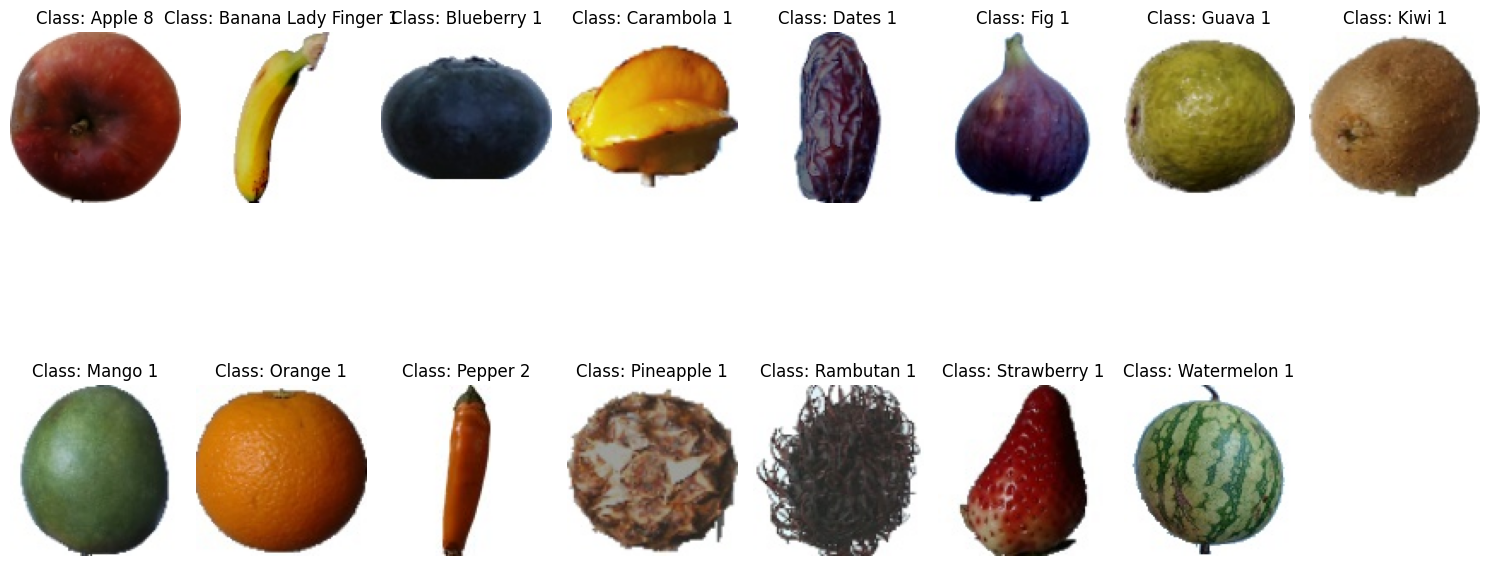

In [27]:
num_classes = len(classes)
# so that every classes fit,
cols = (num_classes + 1) // 2

plt.figure(figsize=(15, 8))
for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    # Get all images in this class folder
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if images: 
        #Select one image randomly
        random_img_name = random.choice(images)
        img_path = os.path.join(class_path, random_img_name)

    #Load and plot
    img = mpimg.imread(img_path)
    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {class_name}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Checking for corrupt image

In [28]:
from PIL import Image

#List to keep track of removed files
corrupted_images = []

for class_name in classes:
  class_path = os.path.join(train_dir, class_name)
  #Skip directories, check only files
  for filename in os.listdir(class_path):
    image_path = os.path.join(class_path, filename)

    if os.path.isfile(image_path):
      try:
        #Attempt to open and verify the image
        with Image.open(image_path) as img:
          img.verify() #verify image content without loading the whole file
      except (IOError, SyntaxError) as e:
        #if error is raised, file is likely corrupted
        os.remove(image_path)
        corrupted_images.append(image_path)
        print(f"Removed corrupt image: {image_path}")
#final Reporting
if not corrupted_images:
  print("No corrupt images found")
else:
  print(f"Total number of removed images: {len(corrupted_images)}")

No corrupt images found


Train

In [29]:
import tensorflow as tf

# Set parameters to match your actual data
img_height = 100 
img_width = 100 
batch_size = 32 # 32 is a standard starting point for stable training

# Create Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Create Validation Dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 7635 files belonging to 15 classes.
Using 6108 files for training.
Found 7635 files belonging to 15 classes.
Using 1527 files for validation.


In [31]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [34]:
from tensorflow.keras import layers, models

#Data augmentation layer
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model = models.Sequential([

    layers.Input(shape=(img_height, img_width, 3)),
    #Data Augmentation
    data_augmentation,
    # 1. Input & Rescaling (Option 1 from before)
    layers.Rescaling(1./255, input_shape=(img_height,img_width, 3)),

    # 2. Convolutional Layer 1 (From your workshop specs)
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', strides=1, activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # 3. Convolutional Layer 2 (From your workshop specs)
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', strides=1, activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # 4. Flattening (Crucial: This turns 2D maps into a 1D vector for the final decision)
    # layers.Flatten(),

    #Using global pooling by AI suggestion
    layers.GlobalAveragePooling2D(),

    # 5. Dense Layer (Hidden layer to interpret features)
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # 6. Output Layer (Must be 15 because you have 15 classes of fruit!)
    layers.Dense(num_classes, activation='softmax') 
])

#Check the architecture summary
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,303 (63.68 KB)

 Trainable params: 16,303 (63.68 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,303 (63.68 KB)

 Trainable params: 16,303 (63.68 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# EarlyStopping stops training if val_loss doesn't improve for 5 epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ModelCheckpoint saves only the version with the best validation accuracy
checkpoint = ModelCheckpoint(
    'best_fruit_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [37]:
# --- 6. EXECUTE TRAINING ---
epochs = 25
print("\nStarting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping, checkpoint]
)


Starting training...
Epoch 1/25
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.1669 - loss: 2.4792
Epoch 1: val_accuracy improved from -inf to 0.62475, saving model to best_fruit_model.keras
191/191 ━━━━━━━━━━━━━━━━━━━━ 48s 232ms/step - accuracy: 0.1674 - loss: 2.4773 - val_accuracy: 0.6248 - val_loss: 1.1711
Epoch 2/25
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.5797 - loss: 1.0829
Epoch 2: val_accuracy improved from 0.62475 to 0.87885, saving model to best_fruit_model.keras
191/191 ━━━━━━━━━━━━━━━━━━━━ 47s 246ms/step - accuracy: 0.5801 - loss: 1.0821 - val_accuracy: 0.8788 - val_loss: 0.5026
Epoch 3/25
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.7923 - loss: 0.5514
Epoch 3: val_accuracy improved from 0.87885 to 0.88605, saving model to best_fruit_model.keras
191/191 ━━━━━━━━━━━━━━━━━━━━ 46s 239ms/step - accuracy: 0.7924 - loss: 0.5511 - val_accuracy: 0.8861 - val_loss: 0.2998
Epoch 4/25
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.8523

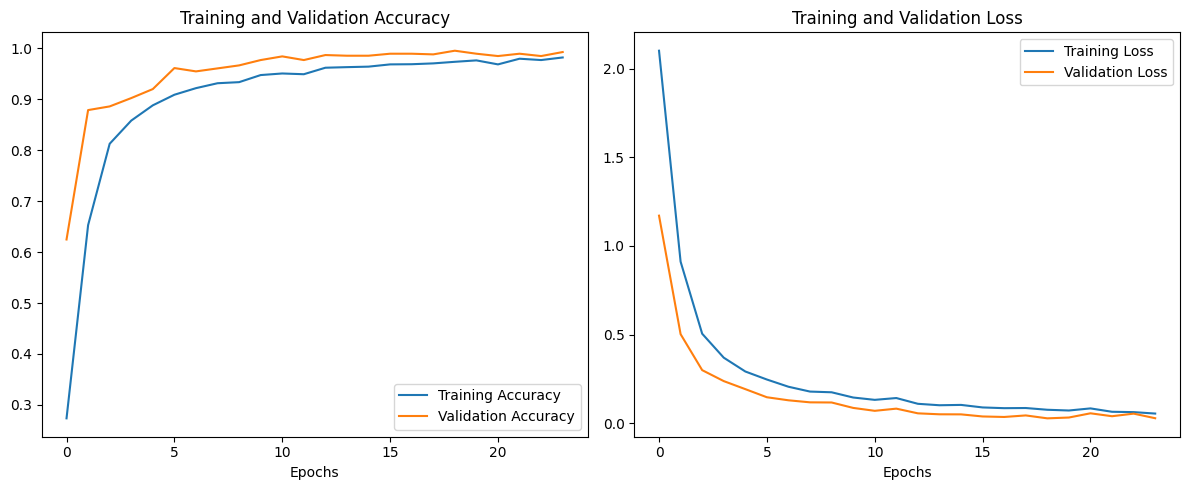

In [38]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Test set

In [39]:
import tensorflow as tf

# Define path to the test folder
test_dir = '/kaggle/input/datasets/pratikkarki106/fruits-classification/fruits-360/Test'

# Create the test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(100, 100), # Must match training size
    interpolation='nearest',
    batch_size=32,         # Matching your requested training batch size
    shuffle=False          # No need to shuffle for testing
)

# Normalize the test images (Crucial step!)
# normalization_layer = tf.keras.layers.Rescaling(1./255)
# test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Found 2557 files belonging to 15 classes.


In [40]:
import tensorflow as tf


# 1. Save the model to an .h5 file
model_filename = 'fruit_classifier_model.h5'
model.save(model_filename)
print(f"Model saved successfully to {model_filename}")

# 2. Load the saved model
# This creates a new 'loaded_model' object independent of the original 'model'
loaded_model = tf.keras.models.load_model(model_filename)
print("Model loaded successfully.")

# 3. Re-evaluate on the test set
# We use the test_ds we created in Task 5
print("\n--- Re-evaluating Loaded Model ---")
loss, accuracy = loaded_model.evaluate(test_ds)

print(f"Loaded Model Test Accuracy: {accuracy * 100:.2f}%")

Model saved successfully to fruit_classifier_model.h5
Model loaded successfully.

--- Re-evaluating Loaded Model ---
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.9922 - loss: 0.0398
Loaded Model Test Accuracy: 99.45%



CLASSIFICATION REPORT
                      precision    recall  f1-score   support

             Apple 8       1.00      1.00      1.00       228
Banana Lady Finger 1       0.93      1.00      0.97       152
         Blueberry 1       1.00      1.00      1.00       154
         Carambola 1       1.00      0.93      0.97       166
             Dates 1       1.00      1.00      1.00       166
               Fig 1       1.00      1.00      1.00       234
             Guava 1       1.00      1.00      1.00       166
              Kiwi 1       1.00      1.00      1.00       156
             Mango 1       1.00      1.00      1.00       166
            Orange 1       1.00      1.00      1.00       160
            Pepper 2       1.00      0.99      0.99       158
         Pineapple 1       1.00      1.00      1.00       166
          Rambutan 1       1.00      1.00      1.00       164
        Strawberry 1       0.98      1.00      0.99       164
        Watermelon 1       1.00      1.00     

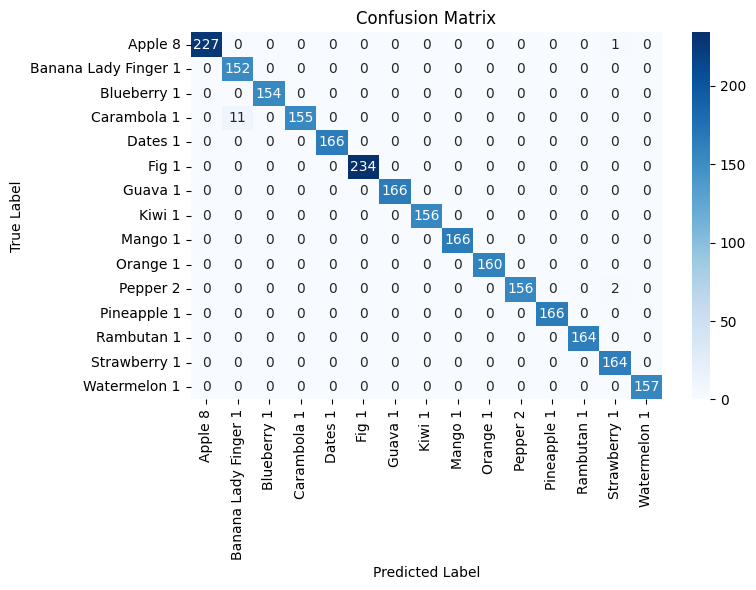

In [41]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get the true labels and images from the test set
y_true = []
y_pred = []

# Loop through the test dataset to get predictions
for images, labels in test_ds:
    # Make predictions
    preds = loaded_model.predict(images, verbose=0)  # verbose=0 for cleaner output

    # Convert probabilities to digit labels
    pred_labels = np.argmax(preds, axis=1)

    # Store results
    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

# Generate classification report
# The original image_dataset_from_directory has class_names, but after .map() it becomes a _MapDataset
# The `classes` variable is already available in the kernel from a previous cell.
class_names = test_ds.class_names

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))

# Optional: Confusion Matrix for better visualization
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Optional: Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()